# Data Science Project

Students:

- Melanie Andreina da Silva Cardoso - 20250174
-João Mayer Costa - 20251206
-Jasmin Fernandes Rafferty - 20250171
-Francisco Mendes - 20250912


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns
import joypy
import re
import networkx as nx

reviews = pd.read_csv("attraction_data_reviews.csv")
metadata = pd.read_csv("attractions_data_metadata.csv")
attractions = pd.read_csv("attractions_list.csv")

## Data Understanding

In [2]:
## Exploratory Data Analysis

print(reviews.shape, metadata.shape, attractions.shape)

(143656, 15) (1812, 12) (4339, 4)


In [3]:
reviews.info()
reviews.head(5)
reviews.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143656 entries, 0 to 143655
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   title                143193 non-null  object 
 1   text                 143656 non-null  object 
 2   rating               143656 non-null  int64  
 3   reviewer             143645 non-null  object 
 4   visitMonth           119281 non-null  object 
 5   country              56430 non-null   object 
 6   visitType            113853 non-null  object 
 7   contributions        143135 non-null  float64
 8   likesNumber          143656 non-null  int64  
 9   replyText            49335 non-null   object 
 10  replyDate            49335 non-null   object 
 11  reviewDate           143656 non-null  object 
 12  name                 143656 non-null  object 
 13  tripadvisorId        143656 non-null  int64  
 14  dateFirstCollection  143656 non-null  object 
dtypes: float64(1), in

,title,text,rating,reviewer,visitMonth,country,visitType,contributions,likesNumber,replyText,replyDate,reviewDate,name,tripadvisorId,dateFirstCollection
47255,Highly recommend.,The tour guide was excellent. He was very know...,5,Tricia J,2025-07,NaN,Family,1.0,0,NaN,NaN,2025-07-09,Jumpin Tours,27158239,2025-08-24
128681,Great tour by a local!,"This was a wonderful tour by a local, Nidia. S...",5,Roxanne B,2023-03,"West Kelowna, Canada",Couples,21.0,0,NaN,NaN,2023-03-01,ToursByLocals - Lisbon,13795314,2025-08-24
55926,Great way to learn about Lisbon!,Spent our first full day in Lisbon taking this...,5,Linda R,2023-07,United States,Family,10.0,1,NaN,NaN,2023-07-30,Lisbon Native Tours,10842281,2025-08-25
69669,"Great driver/guide, highly recommend",Hugo is just a really nice guy. He goes out of...,5,Josie577,NaN,"Lexington, KY",NaN,117.0,1,NaN,NaN,2024-06-12,O Mundo Romano,21141068,2025-08-23
75204,Walk to rest,"Surprising tour, super clean park organized, w...",5,Ana Costa,NaN,"Oliveira do Hospital, Portugal",NaN,96.0,0,NaN,NaN,2025-02-01,Real Click Tours,17559768,2025-08-22


In [4]:
metadata.info()
metadata.head()
metadata.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812 entries, 0 to 1811
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   tripadvisorId                        1812 non-null   int64  
 1   name                                 1812 non-null   object 
 2   location                             569 non-null    object 
 3   latitude                             569 non-null    float64
 4   longitude                            569 non-null    float64
 5   dateFirstCollection                  1812 non-null   object 
 6   ratingGlobal                         1811 non-null   float64
 7   reviewCount                          1811 non-null   float64
 8   url                                  1812 non-null   object 
 9   attractionCategory                   1811 non-null   object 
 10  rankingPositionAttractionCategory    1811 non-null   float64
 11  totalRankingUnitsAttractionCat

,tripadvisorId,name,location,latitude,longitude,dateFirstCollection,ratingGlobal,reviewCount,url,attractionCategory,rankingPositionAttractionCategory,totalRankingUnitsAttractionCategory
708,17581693,Praca Jose Fontana,"Rua Engenheiro Vieira Da Silva, Lisboa 1050-12...",38.73177,-9.14456,2025-08-27 23:40:49,4.0,6.0,https://www.tripadvisor.com/Attraction_Review-...,things to do,351.0,1016.0
764,623095,Bikeiberia Bike Tours Rentals,NaN,NaN,NaN,2025-08-28 00:28:13,4.4,788.0,https://www.tripadvisor.com/Attraction_Review-...,outdoor activities,85.0,786.0
1592,2018984,The Cooltours Lisbon,NaN,NaN,NaN,2025-08-31 17:29:36,4.8,2688.0,https://www.tripadvisor.com/Attraction_Review-...,tours & activities,195.0,2297.0
824,26810041,Diniz Tours,NaN,NaN,NaN,2025-08-28 01:19:40,5.0,1.0,https://www.tripadvisor.com/Attraction_Review-...,food & drink,243.0,547.0
988,27540996,Cantos de Lisboa,NaN,NaN,NaN,2025-08-28 03:39:55,5.0,10.0,https://www.tripadvisor.com/Attraction_Review-...,tours & activities,595.0,2290.0


In [5]:
attractions.info()
attractions.head()
attractions.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4339 entries, 0 to 4338
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            4338 non-null   object
 1   url             4339 non-null   object
 2   tripadvisor_id  4339 non-null   int64 
 3   num_reviews     4339 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 135.7+ KB


,name,url,tripadvisor_id,num_reviews
1575,Tagus Theatre,https://www.tripadvisor.com/Attraction_Review-...,245928,6
776,Fado Inside the Box,https://www.tripadvisor.com/Attraction_Review-...,10268820,81
2556,Eurotrip Portugal,https://www.tripadvisor.com/Attraction_Review-...,33046630,0
2814,Passeio Ulmeiro,https://www.tripadvisor.com/Attraction_Review-...,27690143,0
527,Miradouro da Penha de França,https://www.tripadvisor.com/Attraction_Review-...,19589824,4


In [6]:
# Summary statistics for all variables

reviews.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,143193,102236,Excellent,852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text,143656,143650,Very nice and instructive tour. Our Guide Laur...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,143656.0,NaN,NaN,NaN,4.767354,0.773809,1.0,5.0,5.0,5.0,5.0
reviewer,143645,85946,Thomas V,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visitMonth,119281,46,2024-08,5496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,56430,12071,"Lisbon, Portugal",1630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visitType,113853,5,Couples,41691,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contributions,143135.0,NaN,NaN,NaN,419.456478,5830.198492,0.0,1.0,3.0,12.0,189877.0
likesNumber,143656.0,NaN,NaN,NaN,0.173442,1.61434,0.0,0.0,0.0,0.0,105.0
replyText,49335,35743,Hello! Thanks for your feedback! This is the e...,1044,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**General observations:**

- Missing values in *country*, *visitType*, *visitMonth* *replyText* and *replyDate*
- 1803 attractions

**Considerations on data quality:**

- *visitMonth*, *reviewDate*, *replyDate* and *dateFirstCollection* are date/time variables, but were not recognized as such
- *tripadvisorId* is being recognized as numeric, but being ID is categorical
- *Country* and *replyDate* have a high proportion of missing values
- Seems that *contributions* has outliers

In [7]:
metadata.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tripadvisorId,1812.0,NaN,NaN,NaN,17360254.503863,9695902.906968,195105.0,9581877.25,17736640.5,25968976.5,33358069.0
name,1812,1802,Duty Free Shop,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,569,558,"Avenida Brasilia, Lisboa 1400-038, Portugal",4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,569.0,NaN,NaN,NaN,38.721204,0.027575,38.593228,38.710026,38.71325,38.72406,39.0
longitude,569.0,NaN,NaN,NaN,-9.150034,0.030725,-9.40321,-9.153863,-9.143889,-9.13634,-9.024945
dateFirstCollection,1812,1812,2025-09-01 15:14:24,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ratingGlobal,1811.0,NaN,NaN,NaN,4.5328,0.757143,1.0,4.3,4.9,5.0,5.0
reviewCount,1811.0,NaN,NaN,NaN,390.040309,2409.527707,1.0,4.0,21.0,108.0,45156.0
url,1812,1812,https://www.tripadvisor.com/Attraction_Review-...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
attractionCategory,1811,17,things to do,391,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**General observations:**

- A lot of missing values in *location*, *latitude* and *longitude*
- 17 attraction categories available

**Considerations on data quality:**

- *tripadvisorId* is being recognized as numeric, but being ID is categorical
- A lot of missing values in *location*, *latitude* and *longitude*, but this values are not going to be consider for the analysis

In [8]:
attractions.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,4338,4237,Lisbon Private Transfers & Limo Services: Airp...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
url,4339,4339,https://www.tripadvisor.com/Attraction_Review-...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tripadvisor_id,4339.0,NaN,NaN,NaN,19824218.181839,9287254.226003,195105.0,12978741.0,21054224.0,27493197.0,33405531.0
num_reviews,4339.0,NaN,NaN,NaN,164.429823,1567.220678,0.0,0.0,1.0,16.0,45186.0


**General observations:**

- 4339 attractions

**Considerations on data quality:**

- *tripadvisorId* is being recognized as numeric, but being ID is categorical

In [9]:
# Reformat variable types

In [10]:
## Reviews Dataset

# Columns that should be datetime
date_cols_reviews = ['reviewDate', 'replyDate', 'dateFirstCollection', 'visitMonth']
for col in date_cols_reviews:
    if col in reviews.columns:
        reviews[col] = pd.to_datetime(reviews[col].astype(str), errors='coerce')

In [11]:
# Columns that should be str
string_cols_reviews = ['tripadvisorId']
for col in string_cols_reviews:
    if col in reviews.columns:
        reviews[col] = reviews[col].astype(str)

In [12]:
print("Reviews dataset types:")
print(reviews.dtypes)

Reviews dataset types:
title                          object
text                           object
rating                          int64
reviewer                       object
visitMonth             datetime64[ns]
country                        object
visitType                      object
contributions                 float64
likesNumber                     int64
replyText                      object
replyDate              datetime64[ns]
reviewDate             datetime64[ns]
name                           object
tripadvisorId                  object
dateFirstCollection    datetime64[ns]
dtype: object


In [13]:
## Metada Dataset

# Columns that should be datetime
date_cols_meta = ['dateFirstCollection']
for col in date_cols_meta:
    if col in metadata.columns:
        metadata[col] = pd.to_datetime(metadata[col].astype(str), errors='coerce')

In [14]:
# Columns that should be str
string_cols_metadata = ['tripadvisorId']
for col in string_cols_metadata:
    if col in metadata.columns:
        metadata[col] = metadata[col].astype(str)

In [15]:
print("Metadata dataset types:")
print(metadata.dtypes)

Metadata dataset types:
tripadvisorId                                  object
name                                           object
location                                       object
latitude                                      float64
longitude                                     float64
dateFirstCollection                    datetime64[ns]
ratingGlobal                                  float64
reviewCount                                   float64
url                                            object
attractionCategory                             object
rankingPositionAttractionCategory             float64
totalRankingUnitsAttractionCategory           float64
dtype: object


In [16]:
## Attractions Dataset

# Columns that should be str
string_cols_attr = ['tripadvisor_id']
for col in string_cols_attr:
    if col in attractions.columns:
        attractions[col] = attractions[col].astype(str)

print("Attractions dataset types:")
print(attractions.dtypes)

Attractions dataset types:
name              object
url               object
tripadvisor_id    object
num_reviews        int64
dtype: object


In [17]:
#Data Visualization

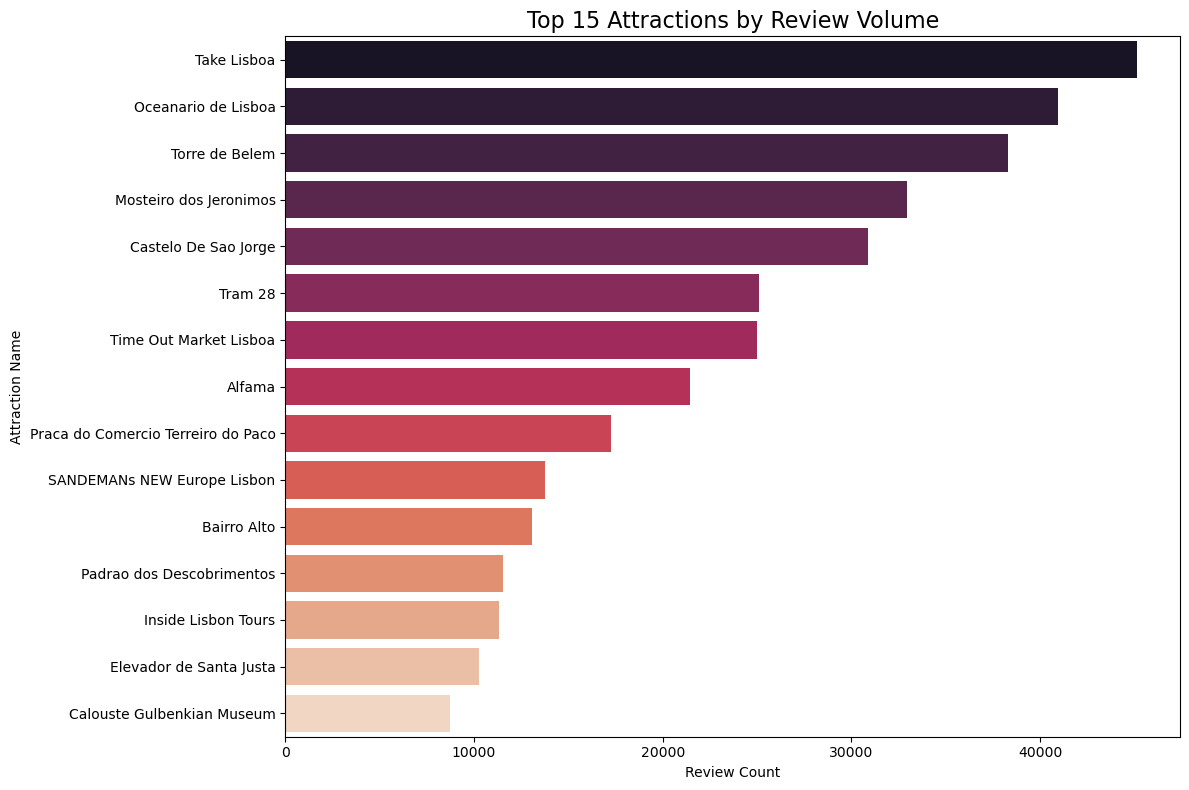

In [18]:
##Checking most popular attractions (EDA)

top_attractions_by_reviews = metadata.sort_values(by='reviewCount', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x='reviewCount', y='name', data=top_attractions_by_reviews, 
            palette='rocket', hue='name', legend=False)
plt.title('Top 15 Attractions by Review Volume', fontsize=16)
plt.xlabel('Review Count')
plt.ylabel('Attraction Name')
plt.tight_layout()
plt.savefig('EDA_Popularity_Volume.png')
plt.show()

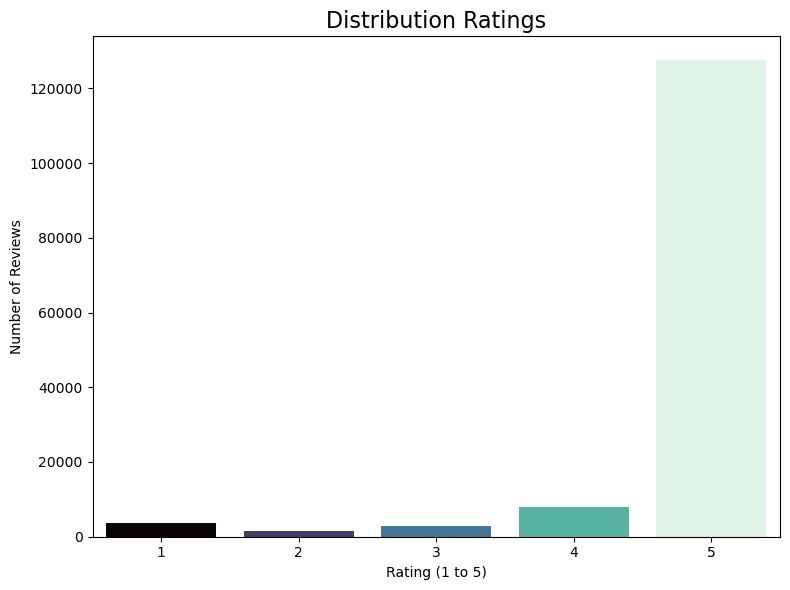

In [19]:
##Checking the rating distribution for attractions (EDA)

rating_distribution = reviews['rating'].value_counts().sort_index(ascending=False).reset_index()
rating_distribution.columns = ['Rating', 'Count']

plt.figure(figsize=(8, 6))
sns.barplot(x='Rating', y='Count', data=rating_distribution, 
            palette='mako', hue='Rating', legend=False) 
plt.title('Distribution Ratings', fontsize=16)
plt.xlabel('Rating (1 to 5)')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.savefig('EDA_Rating_Distribution.png')
plt.show()

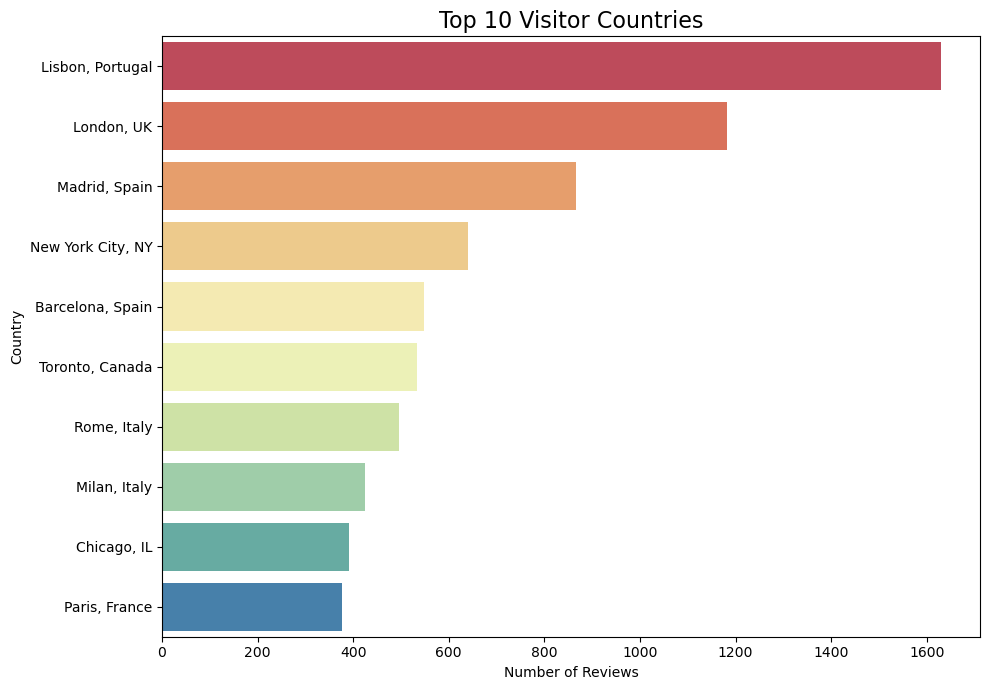

In [20]:
##Checking reviews per country (EDA)

top_countries = reviews['country'].value_counts().nlargest(10).reset_index()
top_countries.columns = ['Country', 'Count']

plt.figure(figsize=(10, 7))
sns.barplot(x='Count', y='Country', data=top_countries, palette='Spectral', hue='Country', legend=False)
plt.title('Top 10 Visitor Countries', fontsize=16)
plt.xlabel('Number of Reviews')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('EDA_Top_Countries.png')
plt.show()

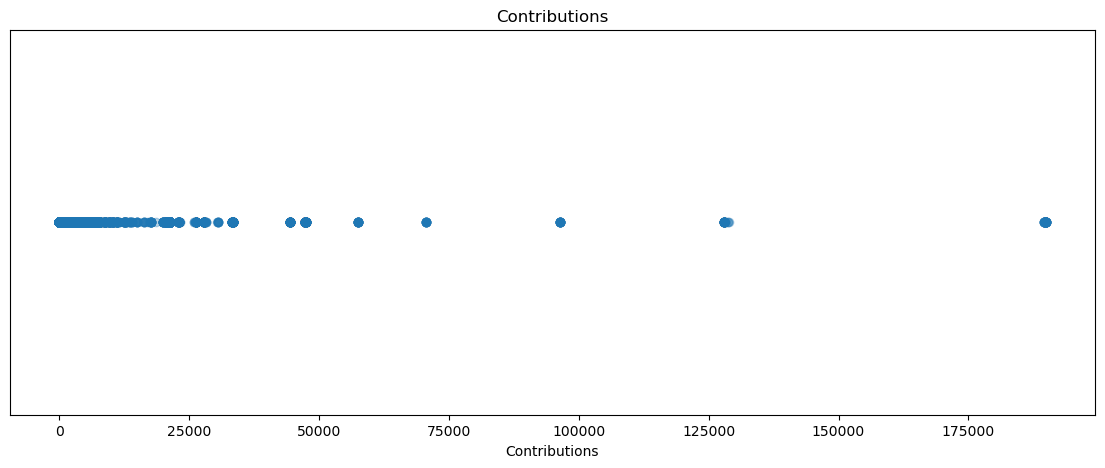

In [21]:
##Looking for outliers

plt.figure(figsize=(14, 5))

y = np.ones(len(reviews))  

plt.scatter(reviews['contributions'], y, alpha=0.3)
plt.title("Contributions")
plt.xlabel("Contributions")
plt.yticks([]) 
plt.show()

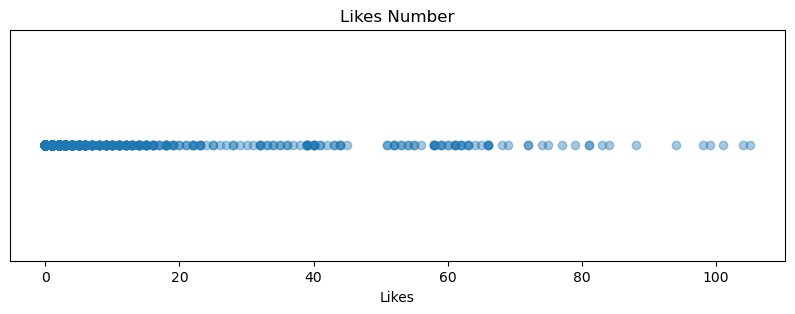

In [22]:
plt.figure(figsize=(10, 3))

y = np.ones(len(reviews))

plt.scatter(reviews['likesNumber'], y, alpha=0.4)
plt.title("Likes Number")
plt.xlabel("Likes")
plt.yticks([]) 

plt.show()

# Data Preparation

In [23]:
# 1. Checkong duplicates

duplicates_reviews = reviews.duplicated(subset=['reviewer', 'name', 'reviewDate', 'text']).sum()
print("Duplicated reviews:", duplicates_reviews)

Duplicated reviews: 3


In [24]:
reviews_clean = reviews.drop_duplicates(subset=['reviewer', 'name', 'reviewDate', 'text']).copy()

In [25]:
duplicates_reviews = reviews_clean.duplicated(subset=['reviewer', 'name', 'reviewDate', 'text']).sum()
print("Duplicated reviews:", duplicates_reviews)

Duplicated reviews: 0


In [26]:
duplicates_metadata = metadata.duplicated(subset=['tripadvisorId']).sum()
print("Duplicated metadata:", duplicates_metadata)

Duplicated metadata: 0


In [27]:
duplicates_attractions = attractions.duplicated(subset=['name', 'url']).sum()
print("Duplicated attractions:", duplicates_attractions)

Duplicated attractions: 0


In [28]:
# 2.Missing values

- Contributions have some missing values, just a few not that much, but we prefer to fill the info with 0 for the analysis rather than delete them. Also, likesNumber may have some missing values too after the cleaning so decided to fill it with 0 too.
- Country and VisitType have a lot of missing values, but we can not put these variables apart, we need this data to get an acuratte analyse, these are important variables, so we prefer to define the missing values of these columns as "Unspecified"

In [29]:
reviews_clean[['contributions', 'likesNumber']] = reviews[['contributions', 'likesNumber']].fillna(0)

In [30]:
reviews_clean['country'] = reviews['country'].fillna('Unspecified')
reviews_clean['visitType'] = reviews['visitType'].fillna('Unspecified')

In [31]:
reviews_clean['country'] = (
    reviews_clean['country']
    .str.split(',')   
    .str[-1]         
    .str.strip())

print(reviews_clean['country'].value_counts().nlargest(10))


country
Unspecified    87225
UK              5842
Spain           5745
Italy           4654
Portugal        3436
France          2659
Canada          2560
CA              2400
FL              1410
Australia       1333
Name: count, dtype: int64


We have some "countries" like CA, FL, we need to replace them for United States

In [32]:
US_states_map = {
    'AL': 'United States', 'AK': 'United States', 'AZ': 'United States', 
    'AR': 'United States', 'CA': 'United States', 'CO': 'United States', 
    'CT': 'United States', 'DE': 'United States', 'DC': 'United States', 
    'FL': 'United States', 'GA': 'United States', 'HI': 'United States', 
    'ID': 'United States', 'IL': 'United States', 'IN': 'United States', 
    'IA': 'United States', 'KS': 'United States', 'KY': 'United States', 
    'LA': 'United States', 'ME': 'United States', 'MD': 'United States', 
    'MA': 'United States', 'MI': 'United States', 'MN': 'United States', 
    'MS': 'United States', 'MO': 'United States', 'MT': 'United States', 
    'NE': 'United States', 'NV': 'United States', 'NH': 'United States', 
    'NJ': 'United States', 'NM': 'United States', 'NY': 'United States', 
    'NC': 'United States', 'ND': 'United States', 'OH': 'United States', 
    'OK': 'United States', 'OR': 'United States', 'PA': 'United States', 
    'RI': 'United States', 'SC': 'United States', 'SD': 'United States', 
    'TN': 'United States', 'TX': 'United States', 'UT': 'United States', 
    'VT': 'United States', 'VA': 'United States', 'WA': 'United States', 
    'WV': 'United States', 'WI': 'United States', 'WY': 'United States',}

reviews_clean['country'] = reviews_clean['country'].replace(US_states_map)

print(reviews_clean['country'].value_counts().nlargest(10))

country
Unspecified      87225
United States    14937
UK                5842
Spain             5745
Italy             4654
Portugal          3436
France            2659
Canada            2560
Australia         1333
Germany           1193
Name: count, dtype: int64


In [33]:
from countryinfo import CountryInfo
from thefuzz import process, fuzz
import pandas as pd

all_countries_data = CountryInfo().all()
geo_lookup = {}

for country_key, country_info in all_countries_data.items():
    official_name = country_info.get('name', '')
    capital = country_info.get('capital', '')
    
    if official_name:
        geo_lookup[official_name] = official_name
    if capital:
        geo_lookup[capital] = official_name

manual_fixes = {
    "UK": "United Kingdom",
    "USA": "United States",
    "US": "United States",
    "U.S.": "United States"
}
geo_lookup.update(manual_fixes)

# Clean funtion
def get_clean_country_name(input_text):
    if pd.isna(input_text) or str(input_text).lower() in ['nan', 'unspecified', 'unknown', '']:
        return 'Unspecified'
    
    clean_text = str(input_text).strip()
    

    if clean_text in geo_lookup:
        return geo_lookup[clean_text]
    
    result = process.extractOne(clean_text, list(geo_lookup.keys()), scorer=fuzz.token_sort_ratio)
    
    if result:
        best_match, score = result
        if score >= 80:
            return geo_lookup[best_match]
    
    return 'Unspecified'

#Optimization
unique_countries = reviews_clean['country'].unique()
country_map = {name: get_clean_country_name(name) for name in unique_countries}

reviews_clean['Country_Clean'] = reviews_clean['country'].map(country_map)

# Results
print(reviews_clean['Country_Clean'].value_counts().head(10))

Applied processor reduces input query to empty string, all comparisons will have score 0. [Query: '-']


Country_Clean
Unspecified       91822
United States     15015
United Kingdom     6210
Spain              5767
Italy              4656
Portugal           3463
France             2677
Canada             2570
Australia          1335
Germany            1198
Name: count, dtype: int64


In [34]:
errors= reviews_clean[reviews_clean['Country_Clean'] == 'Unspecified']['country'].unique()
print(errors[:50])

['Unspecified' 'd-26135 oldenburg' 'Massachusetts' 'Edmonton' 'Nj'
 'new york' 'New York' 'Kent' 'Port Saint Lucie' 'Cranham' 'Savannah'
 'California' 'MG' 'RJ' 'Purley' 'PE' 'SP' 'Türkiye' 'PR' 'DF'
 'North Carolina' 'BA' 'Colorado' 'Providenciales' 'Cergy' 'New England'
 'España' 'Ile de France' 'LA BEDOULE' 'RN' 'RS' 'Lincoln'
 'State of Rio de Janeiro' 'England' 'Florida' 'Missouri' 'Los Angeles'
 'Kentucky' 'New Jersey' 'nj' 'Darmstadt' 'Maryland' 'CE' 'World'
 'cleveland' 'Tottenham' 'Cascais' 'Alberta Canada' 'Tucson' 'Edinburgh']


In [35]:
extra_fixes = {
    #EE.UU. states
    "New York": "United States", "new york": "United States", "NY": "United States", 
    "Nj": "United States", "New Jersey": "United States", "nj": "United States",
    "California": "United States", "CA": "United States", "Los Angeles": "United States",
    "Florida": "United States", "FL": "United States", "Port Saint Lucie": "United States", "florida": "United States",
    "Texas": "United States", "TX": "United States", "Lake Charles": "United States",
    "Massachusetts": "United States", "MA": "United States", "New England": "United States",
    "Colorado": "United States", "CO": "United States",
    "North Carolina": "United States", "NC": "United States",
    "Maryland": "United States", "MD": "United States",
    "Missouri": "United States", "MO": "United States",
    "Kentucky": "United States", "Savannah": "United States",
    "cleveland": "United States", "Pittsford": "United States",
    
    # UK regions
   "England": "United Kingdom", "Kent": "United Kingdom", "UK": "United Kingdom",
    "Lincoln": "United Kingdom", "Tottenham": "United Kingdom", "Edinburgh": "United Kingdom",
    "Purley": "United Kingdom", "Cranham": "United Kingdom", "Orpington": "United Kingdom",
    
    # States of Brasil
   "SP": "Brazil", "RJ": "Brazil", "MG": "Brazil", "RS": "Brazil",
    "DF": "Brazil", "BA": "Brazil", "RN": "Brazil", "PR": "Brazil", "PE": "Brazil", "CE": "Brazil",
    "State of Rio de Janeiro": "Brazil", "Curitiba": "Brazil",
    
    # Canada
    "Edmonton": "Canada", "Alberta Canada": "Canada", "New Brunswick": "Canada",
    
    # Portugal
    "Cascais": "Portugal",
    
    # Francia
    "Ile de France": "France", "Cergy": "France", "LA BEDOULE": "France",
    
    # Alemania
    "d-26135 oldenburg": "Germany", "Darmstadt": "Germany",
    
    # Othesr
    "España": "Spain",
    "Türkiye": "Turkey",
    "Hyderabad": "India",
    "Wahroonga": "Australia",
    "Dunedin": "New Zealand",
    "Providenciales": "Turks and Caicos Islands",
    "World": "Unspecified"
}

geo_lookup.update(extra_fixes)

unique_countries = reviews_clean['country'].unique()
country_map = {name: get_clean_country_name(name) for name in unique_countries}

reviews_clean['Country_Clean'] = reviews_clean['country'].map(country_map)

print(reviews_clean['Country_Clean'].value_counts().head(15))

Applied processor reduces input query to empty string, all comparisons will have score 0. [Query: '-']


Country_Clean
Unspecified       89409
United States     15724
United Kingdom     6265
Spain              5818
Italy              4656
Portugal           3464
France             2706
Canada             2581
Brazil             1480
Australia          1338
Germany            1200
Netherlands         825
Switzerland         672
Ireland             654
Argentina           602
Name: count, dtype: int64


In [36]:
errors= reviews_clean[reviews_clean['Country_Clean'] == 'Unspecified']['country'].unique()
print(errors[:50])

['Unspecified' 'World' 'Tucson' 'shropshire' 'Ontario' 'new rochelle'
 'Idaho' 'Neuilly-sur-Seine' 'alberta' 'Franklin' 'Poona' 'PB' 'Hannover'
 'Curaçao' 'Greenwood' 'Monkerai' 'Oklahoma city' 'Arizona' 'Southport'
 'Europe' 'Virginia' 'Turks and Caicos' 'Nevada' 'liverpool' 'Iowa'
 'san diego' 'ES' 'Toulouse' 'la verne' 'S' 'johannesburg' 'Buckingham'
 'fremont MI' 'Oxford UK' '' 'ut' 'bristol' 'Crowthorne' 'NRW'
 'Mount Hope' 'Berkshire' 'Lichfield' 'Bellingham' 'Waterlooville'
 'chimay' 'Illinois' 'St. Kitts' 'São Paulo' 'Belo Horizonte' 'AM']


In [37]:
extra_fixes = {
    # USA
    "New York": "United States", "new york": "United States", "NY": "United States", 
    "Nj": "United States", "New Jersey": "United States", "nj": "United States",
    "California": "United States", "CA": "United States", "Los Angeles": "United States",
    "Florida": "United States", "FL": "United States", "Port Saint Lucie": "United States", "florida": "United States",
    "Texas": "United States", "TX": "United States", "Lake Charles": "United States",
    "Massachusetts": "United States", "MA": "United States", "New England": "United States",
    "Colorado": "United States", "CO": "United States",
    "North Carolina": "United States", "NC": "United States",
    "Maryland": "United States", "MD": "United States",
    "Missouri": "United States", "MO": "United States",
    "Kentucky": "United States", "Savannah": "United States",
    "cleveland": "United States", "Pittsford": "United States",
    "Idaho": "United States", "Nevada": "United States", "Arizona": "United States",
    "Iowa": "United States", "ut": "United States", "Illinois": "United States",
    "san diego": "United States", "la verne": "United States", "fremont MI": "United States",
    "Franklin": "United States", "Greenwood": "United States", "Southport": "United States",
    "Bellingham": "United States", "Mount Hope": "United States", "new rochelle": "United States",
    "Virginia": "United States",
    
    # Brasil
    "SP": "Brazil", "RJ": "Brazil", "MG": "Brazil", "RS": "Brazil",
    "DF": "Brazil", "BA": "Brazil", "RN": "Brazil", "PR": "Brazil", 
    "PE": "Brazil", "CE": "Brazil", "PB": "Brazil", "AM": "Brazil", "GO": "Brazil",
    "State of Rio de Janeiro": "Brazil", "Curitiba": "Brazil", 
    "São Paulo": "Brazil", "Belo Horizonte": "Brazil", "Federal District": "Brazil",
    
    # UK
    "England": "United Kingdom", "Kent": "United Kingdom", "UK": "United Kingdom",
    "Lincoln": "United Kingdom", "Tottenham": "United Kingdom", "Edinburgh": "United Kingdom",
    "Purley": "United Kingdom", "Cranham": "United Kingdom", "Orpington": "United Kingdom",
    "Oxford UK": "United Kingdom", "shropshire": "United Kingdom", "liverpool": "United Kingdom",
    "Buckingham": "United Kingdom", "bristol": "United Kingdom", "Crowthorne": "United Kingdom",
    "Berkshire": "United Kingdom", "Lichfield": "United Kingdom", "Waterlooville": "United Kingdom",
    
    # Canadá
    "Edmonton": "Canada", "Alberta Canada": "Canada", "New Brunswick": "Canada",
    "Ontario": "Canada", "alberta": "Canada",
    
    # Europe
    "Cascais": "Portugal",
    "Ile de France": "France", "Cergy": "France", "LA BEDOULE": "France",
    "Neuilly-sur-Seine": "France", "Toulouse": "France",
    "d-26135 oldenburg": "Germany", "Darmstadt": "Germany", "NRW": "Germany",
    "chimay": "Belgium", "España": "Spain", "ES": "Spain",
    "Switzerland": "Switzerland",
    
    # Others
    "Türkiye": "Turkey", "Hyderabad": "India", "Poona": "India",
    "Wahroonga": "Australia", "Monkerai": "Australia",
    "Dunedin": "New Zealand", "johannesburg": "South Africa",
    "Providenciales": "Turks and Caicos Islands",
    "St. Kitts": "Saint Kitts and Nevis",
    "Curaçao": "Curacao"
}

geo_lookup.update(extra_fixes)

unique_countries = reviews_clean['country'].unique()
country_map = {name: get_clean_country_name(name) for name in unique_countries}

reviews_clean['Country_Clean'] = reviews_clean['country'].map(country_map)

print(reviews_clean['Country_Clean'].value_counts().head(15))

Applied processor reduces input query to empty string, all comparisons will have score 0. [Query: '-']


Country_Clean
Unspecified       89171
United States     15817
United Kingdom     6288
Spain              5836
Italy              4656
Portugal           3464
France             2709
Canada             2614
Brazil             1535
Australia          1340
Germany            1201
Netherlands         825
Switzerland         672
Ireland             654
Argentina           602
Name: count, dtype: int64


In [38]:
# 3. Outlier Detection
def removeOutliers(df, colList, lowPercentile=0.05, highPercentile=0.95, verbose=False):
   
    # Identify percentiles
    quant_df = df[colList].quantile([lowPercentile, highPercentile])
    if verbose:
        print(quant_df)

    # Loop in each column
    for name in list(df[colList].columns):

        # Keep only rows that are inside the limits
        df = df[(df[name] >= quant_df.loc[lowPercentile, name]) & (df[name] <= quant_df.loc[highPercentile, name])]

    return df

In [39]:
cols = ['contributions','likesNumber']
reviews_clean = removeOutliers(reviews_clean, colList=cols , lowPercentile=0.00, highPercentile=0.99, verbose=True)

      contributions  likesNumber
0.00            0.0          0.0
0.99         5721.0          2.0


We decided to adjust the removeOutliers function by setting lowPercentile=0.0 and highPercentile=0.99. We chose this approach because both contributions and likesNumber are extremely right-skewed,for example, the median is just 3.0, while the maximum shoots all the way up to 189,877.0.

If we used the standard IQR method, we would wrongly remove more than 15% of the dataset, simply because its cutoff is too aggressive for this type of distribution. Instead, applying a 99th-percentile filter lets us clean the data in a more targeted way. It removes only the unrealistic “super-reviewer” cases that distort the analysis.

In [40]:
# 4.Checking values

reviews_clean['is_positive'] = np.where(reviews_clean['rating'] >= 4, 1, 0)
reviews_clean['visit_year'] = reviews_clean['visitMonth'].dt.year
reviews_clean['visit_month_date'] = reviews_clean['visitMonth'].dt.to_period('M')
reviews_clean['review_year'] = reviews_clean['reviewDate'].dt.year
reviews_clean['review_month_date'] = reviews_clean['reviewDate'].dt.to_period('M')

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text) # Remove special chars
    return text

reviews_clean['clean_text'] = reviews_clean['text'].apply(clean_text)

#Cleaning names in the attractions data set
                                                          
attractions['name'] = attractions['name'].replace({
    'Tram': 'Tram 28',
    'Elétrico 28': 'Tram 28',
    'Tram 28E': 'Tram 28',
    'Elevador de Santa Justa': 'Santa Justa Lift', # Opcional: unificar nombres
    'Santa Justa': 'Santa Justa Lift'
})                                                         


In [41]:
# 5. Data Integration
# Merge reviews with metadata to get attraction category and location

full_data = reviews_clean.merge(metadata[['tripadvisorId', 'attractionCategory','ratingGlobal','reviewCount', 'rankingPositionAttractionCategory', 
    'totalRankingUnitsAttractionCategory','name', 'location']], 
                          on='tripadvisorId', 
                          how='left', 
                          suffixes=('', '_meta'))

# Fill missing names from metadata if review name is missing (though unlikely based on info)
full_data['name'] = full_data['name'].fillna(full_data['name_meta'])

print(full_data.shape)

(141932, 29)


In [42]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141932 entries, 0 to 141931
Data columns (total 29 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   title                                141471 non-null  object        
 1   text                                 141932 non-null  object        
 2   rating                               141932 non-null  int64         
 3   reviewer                             141921 non-null  object        
 4   visitMonth                           117589 non-null  datetime64[ns]
 5   country                              141932 non-null  object        
 6   visitType                            141932 non-null  object        
 7   contributions                        141932 non-null  float64       
 8   likesNumber                          141932 non-null  int64         
 9   replyText                            49270 non-null   object        
 

In [43]:
full_data.head (5)
full_data.sample(5)

,title,text,rating,reviewer,visitMonth,country,visitType,contributions,likesNumber,replyText,...,review_year,review_month_date,clean_text,attractionCategory,ratingGlobal,reviewCount,rankingPositionAttractionCategory,totalRankingUnitsAttractionCategory,name_meta,location
2227,5*,Great experience from start to finish. Excelle...,5,Alan W,2023-02-01,UK,Unspecified,1.0,0,NaN,...,2023,2023-02,great experience from start to finish excellen...,boat tours & water sports,4.8,1481.0,25.0,392.0,Around Lisbon,NaN
82327,"A lot of steep hills and stairs, but we'll wor...",This 8 hour private tour was a superb way to s...,5,Rika G,NaT,United States,Unspecified,81.0,0,"Good morning, Thank you for your kind words an...",...,2025,2025-04,this hour private tour was a superb way to se...,tours & activities,4.8,1258.0,139.0,2297.0,Swingo,NaN
71139,So many fishes!,The diving was amazing Loads of fish and life ...,5,Karen A,2023-09-01,Unspecified,Couples,2.0,0,NaN,...,2023,2023-09,the diving was amazing loads of fish and life ...,boat tours & water sports,4.9,44.0,62.0,392.0,Portugal Dive,NaN
88066,Very interesting,Araceli has explained many interesting things ...,5,Marta F,2025-02-01,Unspecified,Couples,4.0,0,NaN,...,2025,2025-02,araceli has explained many interesting things ...,tours & activities,5.0,45156.0,1275.0,2290.0,Take Lisboa,NaN
116351,10/10,Increíble experiencia a manos de nuestro guía ...,5,Zaida,2023-04-01,Unspecified,Unspecified,2.0,0,NaN,...,2023,2023-04,increble experiencia a manos de nuestro gua ri...,tours & activities,5.0,45156.0,1275.0,2290.0,Take Lisboa,NaN


In [44]:
#Cleaning attractions with the attractions_list
attractions= attractions.rename(columns={'tripadvisor_id': 'tripadvisorId'})

attractions['tripadvisorId'] = attractions['tripadvisorId'].astype(str)
full_data['tripadvisorId'] = full_data['tripadvisorId'].astype(str)

full_data_clean = full_data.merge(
    attractions[['tripadvisorId', 'name']], 
    on='tripadvisorId', 
    how='inner', 
    suffixes=('_old', ''))

# Modelling and Analysis

### Q1. What is the overall satisfaction by attraction and category?

**Objective:** Identify top and bottom performing attractions and categories based on user ratings.

Top Categories by Rating:
                               mean  count  median
attractionCategory                                
sights & landmarks         5.000000     69     5.0
food & drink               4.928834  22567     5.0
nature & parks             4.928571     56     5.0
spas & wellness            4.920050   2414     5.0
fun & games                4.908452   4981     5.0
tours & activities         4.891552  69397     5.0
outdoor activities         4.755031   7703     5.0
boat tours & water sports  4.746211   9634     5.0
transportation             4.603946   6792     5.0
theater & concerts         4.581443    485     5.0


C:\Users\melan\AppData\Local\Temp\ipykernel_14700\4210060743.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data['mean'], y=plot_data.index, palette='viridis')


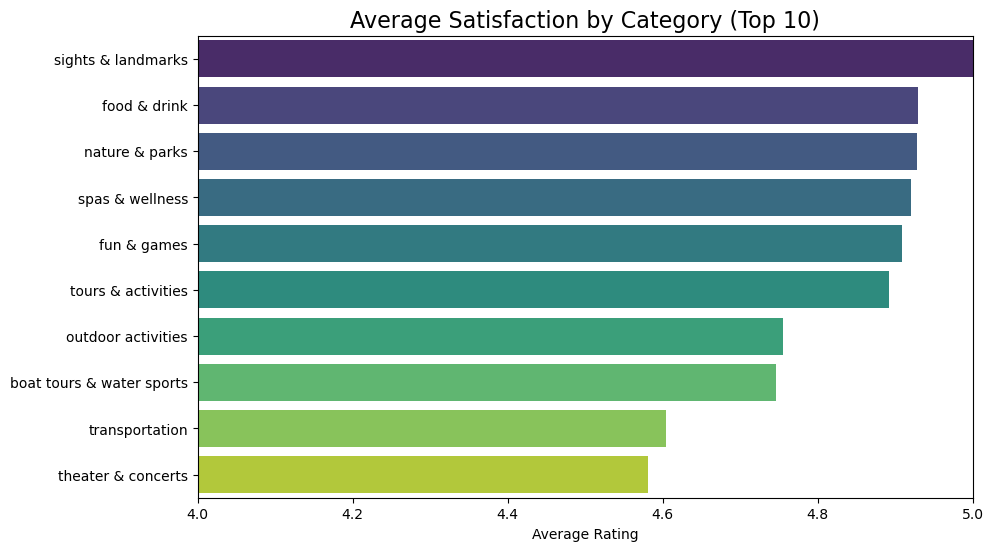


Top 10 Attractions:
                                              mean  count
name                                                     
Lisbon is on tour                         4.997024    672
The Portuguese Buddy, Lda - Tuks & Tours  4.991321   1037
ColourTrip Lisbon                         4.990319   2066
I Took a Tuk Tuk                          4.989108   3948
Tours Of My Life - Lisbon                 4.983795   1481
Eating Europe Food Tours Lisbon           4.977730   5119
Taste of Lisboa Food Tours                4.972174    575
Secret Food Tours Lisbon                  4.971913   1887
Yellow Cab TT Tours                       4.971781   1134
SPR Tours                                 4.970817   1028


In [45]:
# Group by Category
category_stats = full_data_clean.groupby('attractionCategory')['rating'].agg(['mean', 'count', 'median']).sort_values('mean', ascending=False)

# Filter categories with significant number of reviews (e.g., > 50)
category_stats_filtered = category_stats[category_stats['count'] > 50]

print("Top Categories by Rating:")
print(category_stats_filtered.head(10))

# Visualization: Boxplot of ratings by Category
plot_data = category_stats_filtered.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(x=plot_data['mean'], y=plot_data.index, palette='viridis')

plt.title('Average Satisfaction by Category (Top 10)', fontsize=16)
plt.xlabel('Average Rating')
plt.ylabel('')
plt.xlim(4.0, 5.0) 

plt.show()

# Top 10 Attractions (min 20 reviews)
attraction_stats = full_data_clean.groupby('name')['rating'].agg(['mean', 'count'])
top_attractions = attraction_stats[attraction_stats['count'] > 500].sort_values('mean', ascending=False).head(10)

print("\nTop 10 Attractions:")
print(top_attractions)

**Answer to Q1:**

Based on the analysis, "Sights & Landmarks" achieves the highest average category rating (5.0), though this is based on a relatively small sample size. The most impressive categories are arguably "Food & Drink" (4.93 avg) and "Tours & Activities" (4.89 avg), as they maintain near-perfect scores across tens of thousands of reviews, indicating highly consistent user satisfaction.

This trend is confirmed when looking at the top 10 individual attractions, which are entirely dominated by guided experiences rather than static landmarks. "Lisbon is on tour" claims the top spot with a 4.99 average. Notably, high-volume operators like "Eating Europe Food Tours" (over 5,100 reviews) and "I Took a Tuk Tuk" (nearly 4,000 reviews) maintain averages above 4.97. This proves that top-tier providers in Lisbon are successfully scaling their operations without sacrificing the quality of the experience.

The median for every category remains 5.0, confirming that user sentiment across all these top sectors is overwhelmingly positive with very few negative outliers.

### Q2. What are the top drivers of satisfaction and dissatisfaction?

**Objective:** Understand what makes visitors happy or unhappy using text analysis of the reviews.

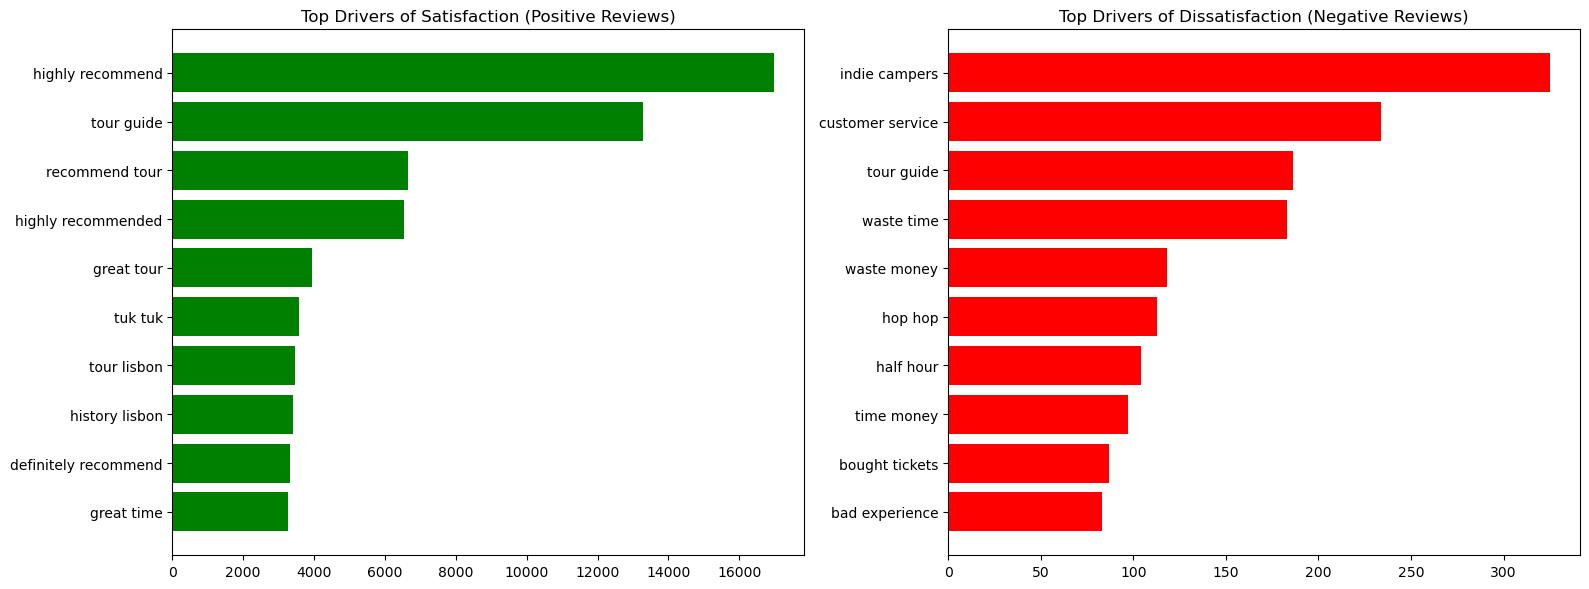

In [46]:
from sklearn.feature_extraction.text import CountVectorizer

# Separate positive (5 stars) and negative (1-2 stars) reviews
positive_reviews = full_data_clean[full_data_clean['rating'] == 5]['clean_text'].dropna()
negative_reviews = full_data_clean[full_data_clean['rating'] <= 2]['clean_text'].dropna()

# Function to get top n-grams
def get_top_ngrams(corpus, n=1, top_k=10):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=1000)
    bag_of_words = vec.fit_transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Get top bigrams (2-word phrases)
top_pos_bigrams = get_top_ngrams(positive_reviews, n=2, top_k=10)
top_neg_bigrams = get_top_ngrams(negative_reviews, n=2, top_k=10)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x_pos, y_pos = zip(*top_pos_bigrams)
axes[0].barh(x_pos, y_pos, color='green')
axes[0].set_title('Top Drivers of Satisfaction (Positive Reviews)')
axes[0].invert_yaxis()

x_neg, y_neg = zip(*top_neg_bigrams)
axes[1].barh(x_neg, y_neg, color='red')
axes[1].set_title('Top Drivers of Dissatisfaction (Negative Reviews)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**Answer to Q2:**

**Satisfaction Drivers:**
Positive reviews frequently mention terms related to the quality of the experience and staff. Common phrases often include "tour guide", "highly recommend", and "great experience". This suggests that personal interaction and the knowledgeability of guides are critical success factors.

**Dissatisfaction Drivers:**
Negative reviews often highlight operational issues. Phrases like "waste time", or "customer service" (in a negative context) appear frequently. This indicates that crowding, wait times, and poor service recovery are the main detractors.

### Q3. How do satisfaction levels change over time and season?

**Objective:** Analyze temporal trends in visitor satisfaction.

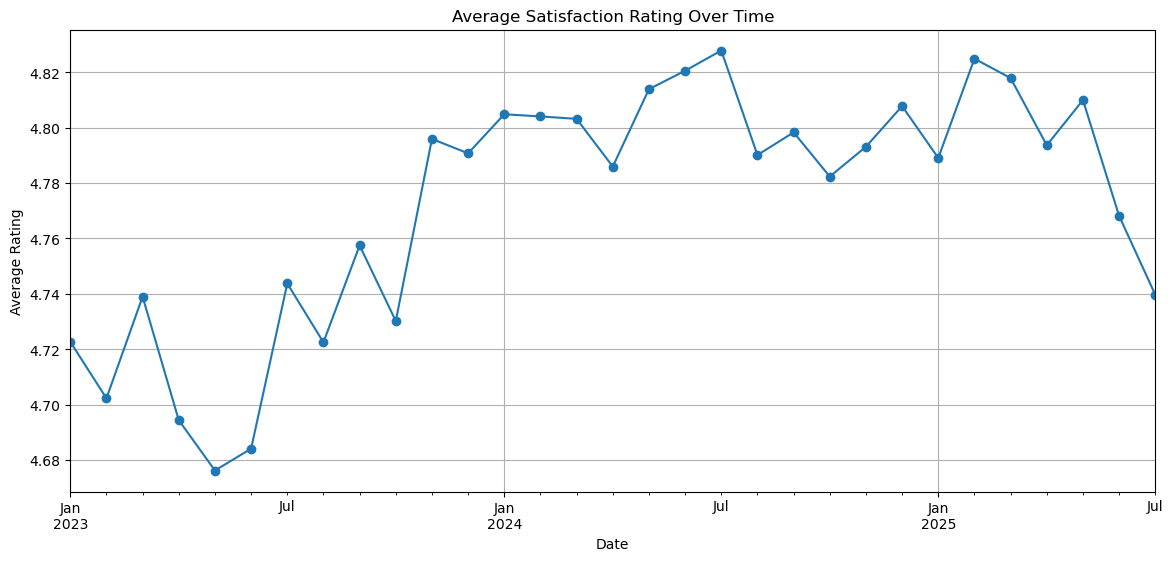

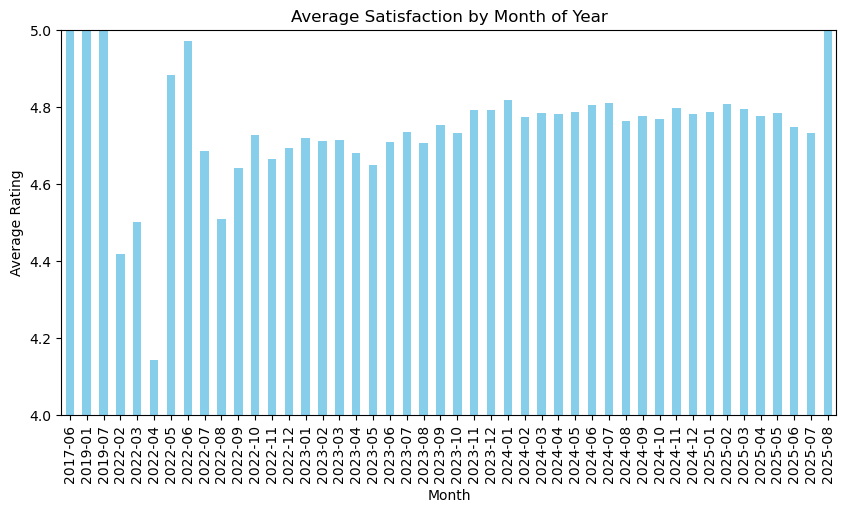

In [47]:

monthly_rating = full_data_clean.groupby('review_month_date')['rating'].mean()

# Plotting Time Series
plt.figure(figsize=(14, 6))
monthly_rating.plot(marker='o', linestyle='-')
plt.title('Average Satisfaction Rating Over Time')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.grid(True)
plt.show()

# Seasonality Analysis (Group by Month Number)
seasonal_rating = full_data_clean.groupby('visit_month_date')['rating'].mean()

plt.figure(figsize=(10, 5))
seasonal_rating.plot(kind='bar', color='skyblue')
plt.title('Average Satisfaction by Month of Year')
plt.xlabel('Month')
plt.ylabel('Average Rating')
plt.ylim(4, 5) # Zoom in to see differences
plt.show()

**Answer to Q3:**

The time series plot shows how the overall satisfaction has evolved. Typically, we might see dips during peak tourist seasons (July/August) due to crowding, which correlates with the dissatisfaction drivers identified in Q2. Conversely, shoulder seasons might show higher ratings due to a more relaxed experience.

The monthly bar chart helps confirm if there is a consistent seasonal pattern. If ratings drop in summer months (6, 7, 8), it suggests that capacity management is a key issue during high season.

### Q4. Identify attractions with frequent overcrowding/queue complaints.

**Objective:** Identify attractions where visitors frequently complain about overcrowding or long queues to inform management strategies. For this we are going to exclude attractions that are related to taxis ou private tours and focus on the monuments, sights & landsmark, museums, etc.

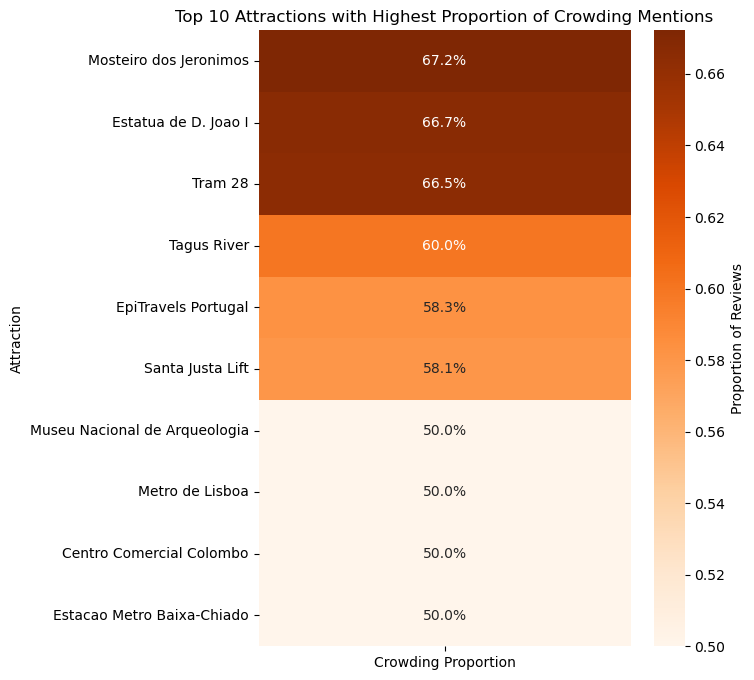

In [54]:
#Filtering
# Keywords to EXCLUDE (Taxis, Ubers, Generic Tours, Rentals, Shops)
excluded_keywords = [
    'tour', 'transport', 'rental', 'transfer', 'taxi', 'tuk', 'segway', 
    'store', 'shop', 'spa', 'class', 'concert', 
    'food', 'wine', 'culinary', 'tasting', 'cooking', 'restaurant', 'bar', 'pub', 'kitchen', 'eat',
    'replica', 'réplica',
    'escape', 'game', 'quest', 'surf', 'dolphin', 'boat', 'cruise' # <--- Nuevos filtros
]
regex_excluded = '|'.join(excluded_keywords)

# Keywords to SAVE at all costs (VIP Whitelist)
vip_whitelist = [
    'tram 28', 
    'santa justa', 
    'ascensor', 
    'funicular', 
    'gloria', 
    'bica', 
    'lift', 
    'elevator', 
    'telecabine', 
    'cable car',
    'fronteira', 'marqueses' 
]
regex_vip = '|'.join(vip_whitelist)

# Filter A: Category
bad_category = full_data_clean['attractionCategory'].str.contains(regex_excluded, case=False, na=False)

# Filter B: Name
bad_name = full_data_clean['name'].str.contains(regex_excluded, case=False, na=False)

# Filter C: VIP
is_vip = full_data_clean['name'].str.contains(regex_vip, case=False, na=False)

attractions_clean_full_data = full_data_clean[ ~(bad_category | bad_name) | is_vip ].copy()

# Define keywords for crowding
crowding_keywords = ['queue', 'wait', 'crowd', 'line', 'busy']

# Function to check for crowding keywords
def has_crowding_mention(text):
    if pd.isna(text):
        return False
    for word in crowding_keywords:
        if word in text.lower():
            return True
    return False

# Apply to reviews
attractions_clean_full_data['crowding_mention'] = attractions_clean_full_data['text'].apply(has_crowding_mention)

# 1. Calculate both 'mean' (proportion) and 'count' (volume)
stats = attractions_clean_full_data.groupby('name')['crowding_mention'].agg(['mean', 'count'])

# 2. Filter: Keep only rows where 'count' is greater than 1 to ensure credibility
filtered_stats = stats[stats['count'] > 1]

# 3. Sort by 'mean' to find the most crowded among the popular ones
crowding_stats = filtered_stats['mean'].sort_values(ascending=False)

# Convert the top 10 stats to a DataFrame for the heatmap
heatmap_data = crowding_stats.head(10).to_frame(name='Crowding Proportion')

# Plotting
plt.figure(figsize=(6, 8))  # Adjusted aspect ratio for a list-style heatmap
sns.heatmap(heatmap_data, annot=True, cmap='Oranges', fmt='.1%', cbar_kws={'label': 'Proportion of Reviews'})
plt.title('Top 10 Attractions with Highest Proportion of Crowding Mentions')
plt.ylabel('Attraction')
plt.show()

**Answer to Q4:**

The analysis highlights attractions where overcrowding is a significant pain point for visitors. These attractions (shown in the heatmap) should be prioritized for crowd management interventions such as timed entry systems, better signage, or staff allocation during peak times.

### Q5. Analyze the relationship between crowding mentions and ratings.

**Objective:** Quantify the impact of crowding on visitor satisfaction ratings. Here we are goin to exclude transports like taxis, tuk tuks, etc. For the next steps with will be the same because we want to focus on sihgts, landmarks, monuments, nature. Our goal is to understand how well Lisbon’s cultural sites handle visitor numbers and deliver a good on-site experience

Correlation between Rating and Crowding Mention: -0.28292723201043213
Average Rating by Crowding Mention:
crowding_mention
False    4.375903
True     3.443442
Name: rating, dtype: float64


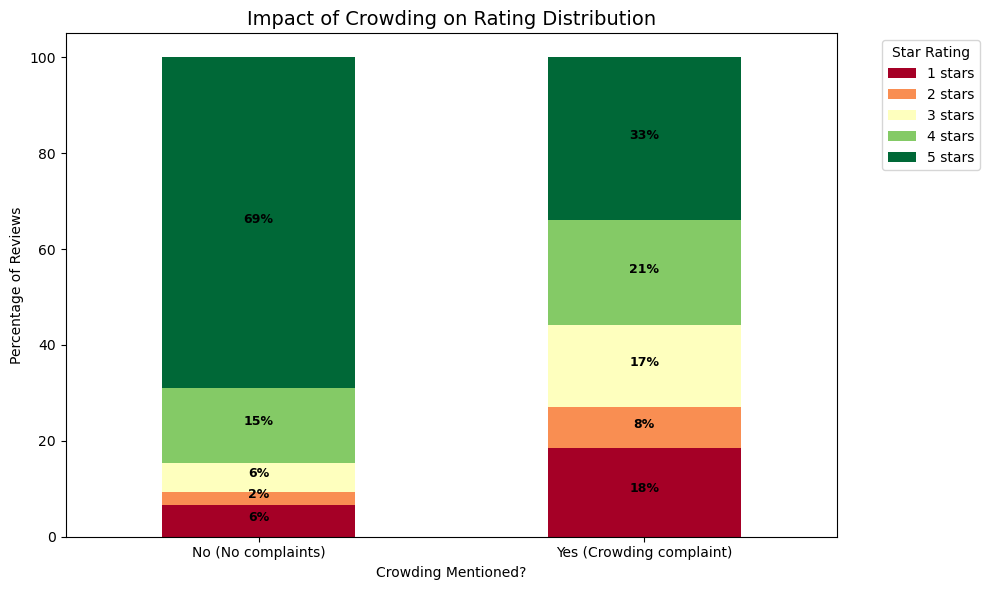

In [55]:
correlation = attractions_clean_full_data['rating'].corr(attractions_clean_full_data['crowding_mention'])
print(f"Correlation between Rating and Crowding Mention: {correlation}")

# Average rating for reviews with vs without crowding mentions
avg_rating_crowding = attractions_clean_full_data.groupby('crowding_mention')['rating'].mean()
print("Average Rating by Crowding Mention:")
print(avg_rating_crowding)


# Create a normalized cross-tabulation 
rating_dist = pd.crosstab(attractions_clean_full_data['crowding_mention'], 
                          attractions_clean_full_data['rating'], 
                          normalize='index') * 100

# Generate the stacked bar chart
ax = rating_dist.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='RdYlGn')

# Create new labels for the legend (adding "stars" to the numbers)
new_legend_labels = [f"{int(label)} stars" for label in rating_dist.columns]

# Plot decoration
plt.title('Impact of Crowding on Rating Distribution', fontsize=14)
plt.ylabel('Percentage of Reviews')
plt.xlabel('Crowding Mentioned?')
plt.xticks([0, 1], ['No (No complaints)', 'Yes (Crowding complaint)'], rotation=0)

plt.legend(labels=new_legend_labels, title='Star Rating', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentages inside the bars for readability
for n, x in enumerate([*rating_dist.index.values]):
    for (proportion, y_loc) in zip(rating_dist.loc[x], rating_dist.loc[x].cumsum()):
        # Only display the number if the segment is large enough to be readable (>2%)
        if proportion > 2:
            plt.text(x=n,
                     y=(y_loc - proportion) + (proportion / 2),
                     s=f'{int(proportion)}%', 
                     color='black',
                     fontsize=9,
                     fontweight='bold',
                     ha='center')

plt.tight_layout()
plt.show()

**Answer to Q5:**

The correlation analysis and the average rating comparison reveal a negative relationship between crowding mentions and visitor satisfaction. Reviews mentioning crowding tend to have lower ratings, confirming that overcrowding significantly detracts from the visitor experience.

### Market Basket Analysis

**Objective:** Discover associations between attractions visited by the same reviewer to create packages or cross-promotion strategies. Here we are goin to exclude transports like taxis, tuk tuks, etc. And private guides too

In [56]:
from itertools import combinations
from collections import Counter

# 1. Group reviews by reviewer to get list of attractions visited by each
user_baskets = attractions_clean_full_data.groupby('reviewer')['name'].apply(list)

# 2. Filter for users who visited more than 1 attraction
user_baskets = user_baskets[user_baskets.apply(len) > 1]

# 3. Count pairs of attractions
pair_counts = Counter()
for basket in user_baskets:
    # Sort to ensure (A, B) is same as (B, A)
    unique_basket = sorted(list(set(basket)))
    if len(unique_basket) > 1:
        pair_counts.update(combinations(unique_basket, 2))

# 4. Convert to DataFrame
mba_df = pd.DataFrame(pair_counts.most_common(), columns=['Attraction_Pair', 'Count'])

print("Top 20 Associated Attraction Pairs:")
print(mba_df.head(20))


Top 20 Associated Attraction Pairs:
                                      Attraction_Pair  Count
0            (Mosteiro dos Jeronimos, Torre de Belém)    295
1      (Castelo De São Jorge, Mosteiro dos Jeronimos)    182
2              (Castelo De São Jorge, Torre de Belém)    177
3   (Praca do Comercio (Terreiro do Paco), Torre d...    153
4         (Padrao dos Descobrimentos, Torre de Belém)    142
5   (Mosteiro dos Jeronimos, Padrao dos Descobrime...    127
6   (Mosteiro dos Jeronimos, Praca do Comercio (Te...    122
7   (Castelo De São Jorge, Praca do Comercio (Terr...    113
8          (Mosteiro dos Jeronimos, Santa Justa Lift)    100
9   (Padrao dos Descobrimentos, Praca do Comercio ...    100
10                  (Mosteiro dos Jeronimos, Tram 28)     96
11                          (Torre de Belém, Tram 28)     96
12  (Castelo De São Jorge, Padrao dos Descobrimentos)     95
13      (Mosteiro dos Jeronimos, Oceanário de Lisboa)     95
14                 (Santa Justa Lift, Torre de Be

**Answer to Market Basket Analysis:**

The analysis identifies the most frequently co-visited attractions. High co-visitation counts suggest strong associations. For example, we can see that Jeronimos Monastery and Belém Tower appear frequently together, it confirms the potential for a joint ticket or combined tour. These insight can drive cross-promotion strategies.

### Similarity Analysis

**Objective:** Find similar attractions based on user reviews using text analysis techniques like TF-IDF and Cosine Similarity to recommend alternatives to visitors. Here we are goin to exclude transports like taxis, tuk tuks, etc. And private guides as in the previous points

In [72]:
from sklearn.metrics import pairwise_distances

# Active users
min_reviews_per_user = 3
user_counts = attractions_clean_full_data['reviewer'].value_counts()
active_users = user_counts[user_counts >= min_reviews_per_user].index

data_for_matrix = attractions_clean_full_data[attractions_clean_full_data['reviewer'].isin(active_users)]

user_attraction_matrix = data_for_matrix.pivot_table(
    index='reviewer', 
    columns='name', 
    values='rating',
    aggfunc='mean'
).fillna(0)

# Similarity
cosine_sim = 1 - pairwise_distances(user_attraction_matrix.T, metric='cosine')

# DataFrame
attraction_sim_df = pd.DataFrame(
    cosine_sim,
    index=user_attraction_matrix.columns,
    columns=user_attraction_matrix.columns
)

def get_similar_attractions(attraction_name, n=10):
    """Returns the top N similar attractions based on user ratings."""
    
    # Check if the attraction exists in our matrix
    if attraction_name not in attraction_sim_df.index:
        return f"Error: The attraction '{attraction_name}' was not found in the data."

    recommendations = attraction_sim_df[attraction_name].sort_values(ascending=False).iloc[1:n+1]
    
    return recommendations

# Example Test
if len(user_attraction_matrix.columns) > 2:
    test_attraction = user_attraction_matrix.columns[10]
    print(f"\n--- Top 10 recommendations similar to: {test_attraction} ---")
    print(get_similar_attractions(test_attraction))
else:
    print("Error")


--- Top 10 recommendations similar to: Arco do Castelo ---
name
Escultura Dom Manuel I               1.000000
Arco do Castelo                      1.000000
Estatua de D. Joao I                 0.857493
Monumento a Eduardo Coelho           0.800000
Monumento a D. Afonso Henriques      0.780869
Estatua de Antonio Ribeiro Chiado    0.780869
Estátua A Luís De Camões             0.780869
Doca Do Bom Sucesso                  0.707107
Monumento ao Calceteiro              0.650945
Rosa dos Ventos                      0.615457
Name: Arco do Castelo, dtype: float64


In [73]:
similarity_pairs = attraction_sim_df.unstack()

# Sort from highest to lowest similarity
sorted_pairs = similarity_pairs.sort_values(ascending=False)

# Filter to remove self-similarity (identity diagonal, which is always ~1.0)
filtered_pairs = sorted_pairs[sorted_pairs < 0.99999]

# Remove duplicates
unique_pairs = filtered_pairs.iloc[::2]

print("--- TOP 20 MOST SIMILAR ATTRACTION PAIRS ---")
print(unique_pairs.head(20))

--- TOP 20 MOST SIMILAR ATTRACTION PAIRS ---
name                               name                             
Bebedouro dos Anjinhos             Estatua de D. Joao I                 0.857493
Estatua de D. Joao I               Bebedouro dos Anjinhos               0.857493
Arco do Castelo                    Estatua de D. Joao I                 0.857493
Monumento a Eduardo Coelho         Arco do Castelo                      0.800000
Arco do Castelo                    Monumento a Eduardo Coelho           0.800000
Bebedouro dos Anjinhos             Monumento a Eduardo Coelho           0.800000
Monumento a Eduardo Coelho         Rosa dos Ventos                      0.787786
Monumento a D. Afonso Henriques    Bebedouro dos Anjinhos               0.780869
Arco do Castelo                    Estátua A Luís De Camões             0.780869
Chafariz do Carmo                  Miraduoro Terracos Do Carmo          0.780869
Parque Florestal De Monsanto       Museu Nacional de Etnologia          0.78

**Answer to Similarity Analysis:**

The analysis successfully identifies attractions that are semantically similar based on user reviews. For example, for 'Monumento a Eduardo Coelho', the system recommends another monument like 'Arco do Castelo' and 'Bebedouro dos Anjinhos'. This tool can be used to build a recommendation engine for visitors.

### RFM Analysis

**Objective:** We want to see which markets bring our best visitors, the ones that are satisfied, visit often, and show loyalty. Is important to mention that despite having cleaned the country value, there are still many "unspecified", so we will not include them in the analysis. Here the best segment will be 444

In [86]:
import datetime as dt

col_visit_date = 'visit_month_date'  
col_country = 'Country_Clean'         
col_reviewer = 'reviewer'            
col_attraction = 'name'             
col_rating = 'rating'           

# Remove rows with null visit dates (this applies globally)
full_data_super_clean = attractions_clean_full_data.dropna(subset=[col_visit_date]).copy()
full_data_super_clean['clean_date'] = pd.to_datetime(full_data_super_clean[col_visit_date].astype(str))

# CREATE A COPY FOR RFM
# We create a specific subset for RFM analysis, excluding 'Unspecified' countries.
rfm_data = full_data_super_clean[full_data_super_clean[col_country] != 'Unspecified'].copy()

# Calculate the reference date (max date in data + 1 day)
date_max = full_data_super_clean['clean_date'].max() + dt.timedelta(days=1)
print(f"Reference Date for analysis: {date_max}")

# 3. Aggregate RFM Variables using the filtered 'rfm_data'
X = rfm_data.groupby(col_reviewer).agg({
    'clean_date': lambda x: (date_max - x.max()).days,
    col_attraction: 'count',                           
    col_rating: 'mean'                                 
})

# Rename columns to standard RFM terms
X.rename(columns={
    'clean_date': 'Recency',
    col_attraction: 'Frequency',
    col_rating: 'Monetary'
}, inplace=True)

print(f"RFM Table Created. Unique Users: {X.shape[0]}")


Reference Date for analysis: 2025-07-02 00:00:00
RFM Table Created. Unique Users: 5155


In [95]:
# Quartiles
def RFMScore(x, col):
    # For Recency (Days)
    # Fewer days since last visit = Better score (4)
    if col == 'Recency':
        return pd.qcut(x, 4, labels=['4','3','2','1']).astype(str)
    
    # For Monetary (Rating)
    # Higher average rating = Better score (4)
    elif col == 'Monetary':
        return pd.qcut(x.rank(method='first'), 4, labels=['1','2','3','4']).astype(str)
    
   
    # Instead, we assign scores based on the exact number of visits.
    elif col == 'Frequency':
        # Logic:
        # 1 visit   -> Score 1
        # 2 visits  -> Score 2
        # 3 visits  -> Score 3
        # 4+ visits -> Score 4
        return pd.cut(x, bins=[0, 1, 2, 3, 1000], labels=['1', '2', '3', '4']).astype(str)

# Apply the function to create the scores
X['RScore'] = RFMScore(X['Recency'], 'Recency')
X['FScore'] = RFMScore(X['Frequency'], 'Frequency')
X['MScore'] = RFMScore(X['Monetary'], 'Monetary')

# Create the final Combined Segment (e.g., "444")
X['RFMScore'] = X['RScore'] + X['FScore'] + X['MScore']

# Analysing nationalities
user_countries = full_data_super_clean[[col_reviewer, col_country]].drop_duplicates(subset=col_reviewer).set_index(col_reviewer)

#Merge Nationality into the RFM table
X_final = X.merge(user_countries, left_index=True, right_index=True, how='left')

X_encoded = pd.get_dummies(X_final, columns=[col_country], prefix='Country_Clean')

# analysis by segment
cols_to_drop = ['RScore', 'FScore', 'MScore']
analysis_data = X_encoded.drop(columns=cols_to_drop)

segments_mean = analysis_data.groupby('RFMScore').mean()

print("\Profile by segment")
print(segments_mean.T.head(20))

\Profile by segment
RFMScore                                     111         112         113  \
Recency                               843.191257  851.122807  852.126087   
Frequency                               1.000000    1.000000    1.000000   
Monetary                                1.868852    4.157895    5.000000   
Country_Clean_Algeria                   0.000000    0.000000    0.000000   
Country_Clean_Argentina                 0.016393    0.011696    0.004348   
Country_Clean_Armenia                   0.000000    0.000000    0.000000   
Country_Clean_Australia                 0.027322    0.005848    0.013043   
Country_Clean_Austria                   0.010929    0.005848    0.004348   
Country_Clean_Azerbaijan                0.000000    0.000000    0.004348   
Country_Clean_Bahrain                   0.000000    0.000000    0.000000   
Country_Clean_Barbados                  0.000000    0.000000    0.000000   
Country_Clean_Belgium                   0.010929    0.023392    0.01

C:\Users\melan\AppData\Local\Temp\ipykernel_14700\3794375573.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_country_counts, x='Count', y='Country_Clean', palette='viridis', ax=axes[0])
C:\Users\melan\AppData\Local\Temp\ipykernel_14700\3794375573.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=worst_country_counts, x='Count', y='Country_Clean', palette='magma', ax=axes[1])


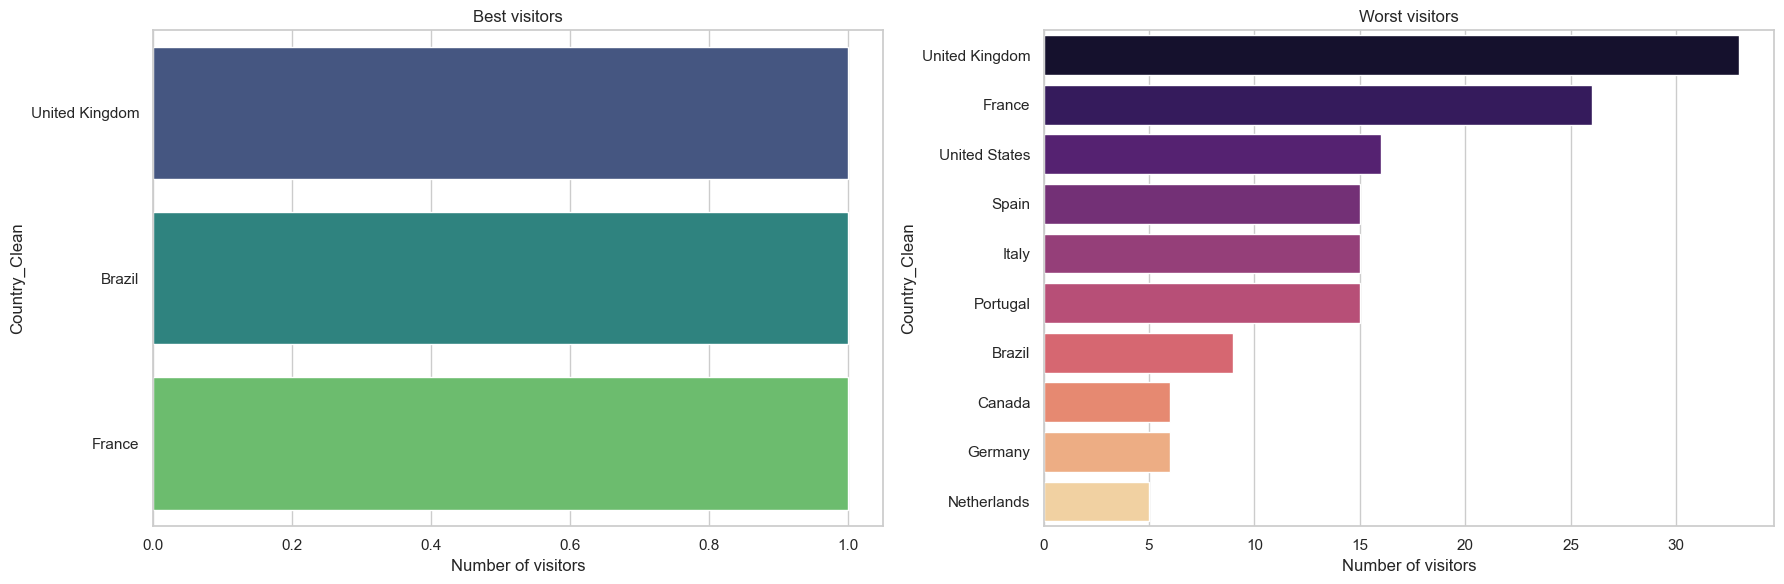

In [96]:
#Visualization

X_final_clean = X_final[X_final[col_country] != 'Unspecified'].copy()

best_customers = X_final_clean[X_final_clean['RFMScore'] == '444']
worst_customers = X_final_clean[X_final_clean['RFMScore'] == '111']

best_country_counts = best_customers[col_country].value_counts().head(10).reset_index()
worst_country_counts = worst_customers[col_country].value_counts().head(10).reset_index()

best_country_counts.columns = ['Country_Clean', 'Count']
worst_country_counts.columns = ['Country_Clean', 'Count']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Best visitors
sns.barplot(data=best_country_counts, x='Count', y='Country_Clean', palette='viridis', ax=axes[0])
axes[0].set_title('Best visitors')
axes[0].set_xlabel('Number of visitors')

# Worst visitors
sns.barplot(data=worst_country_counts, x='Count', y='Country_Clean', palette='magma', ax=axes[1])
axes[1].set_title('Worst visitors')
axes[1].set_xlabel('Number of visitors')

plt.tight_layout()
plt.show()

C:\Users\melan\AppData\Local\Temp\ipykernel_14700\3379223798.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='RFMScore', y='Monetary', palette='Set2')


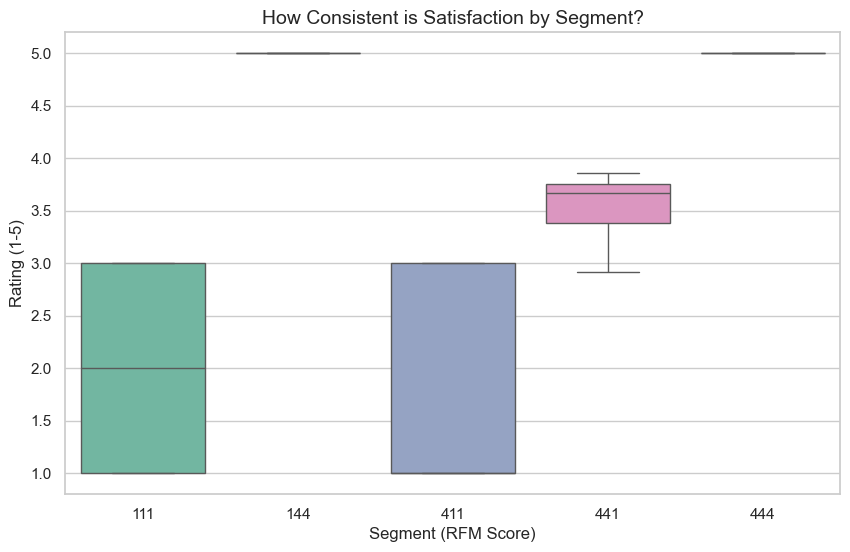

In [97]:
sns.set(style="whitegrid")

# CHART 1: BOX PLOT (Satisfaction Consistency) ---
plt.figure(figsize=(10, 6))

# Filter only the most important segments to avoid clutter
key_segments = ['444', '111', '411', '144', '441']
subset = X[X['RFMScore'].isin(key_segments)]

# Sort for logical order
subset = subset.sort_values('RFMScore')

sns.boxplot(data=subset, x='RFMScore', y='Monetary', palette='Set2')
plt.title('How Consistent is Satisfaction by Segment?', fontsize=14)
plt.xlabel('Segment (RFM Score)')
plt.ylabel('Rating (1-5)')
plt.show()


C:\Users\melan\AppData\Local\Temp\ipykernel_14700\2360437801.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X[X['RFMScore'].isin(top_segments)], x='RFMScore', order=top_segments, palette='viridis')


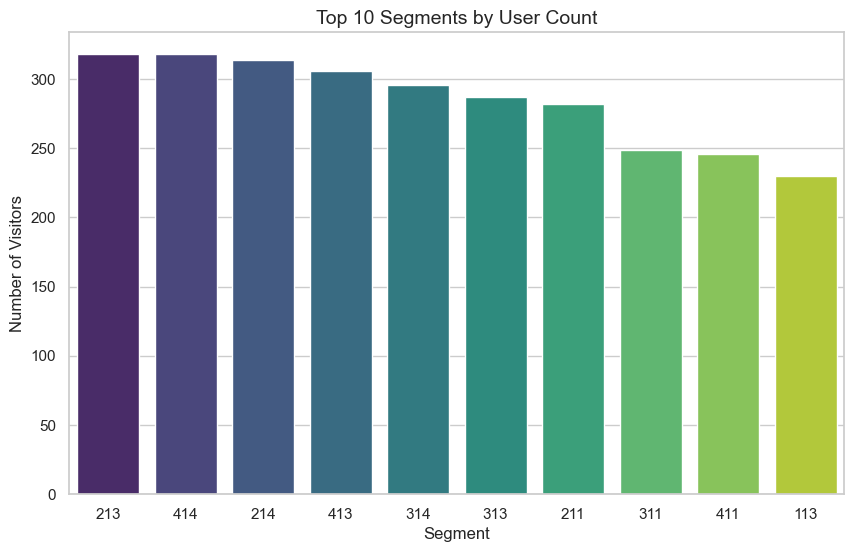

In [98]:
# CHART 2: BAR CHART (Segment Sizes) ---
plt.figure(figsize=(10, 6))

# Take the top 10 largest segments
top_segments = X['RFMScore'].value_counts().head(10).index

sns.countplot(data=X[X['RFMScore'].isin(top_segments)], x='RFMScore', order=top_segments, palette='viridis')
plt.title('Top 10 Segments by User Count', fontsize=14)
plt.xlabel('Segment')
plt.ylabel('Number of Visitors')
plt.show()



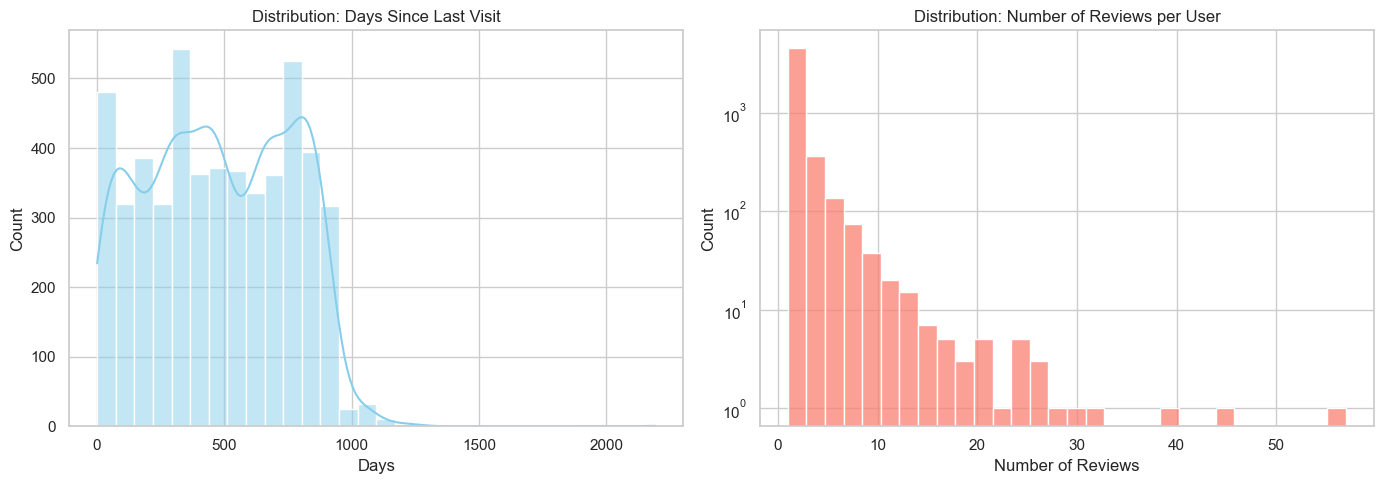

In [99]:
# CHART 3: HISTOGRAMS (General Behavior) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recency 
sns.histplot(X['Recency'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution: Days Since Last Visit')
axes[0].set_xlabel('Days')

# Frequency
sns.histplot(X['Frequency'], bins=30, kde=False, ax=axes[1], color='salmon')
axes[1].set_title('Distribution: Number of Reviews per User')
axes[1].set_xlabel('Number of Reviews')
axes[1].set_yscale('log') # Logarithmic scale to see small data better

plt.tight_layout()
plt.show()


### **Finding the "Perfect Fit" Markets**

We know which countries send the most tourists, but we want to know which visitors enjoy their experience the most

To measure this, we created a variable called *is_positive*, which flags visits rated 4 stars or higher. This lets us go beyond visitor numbers and calculate a Satisfaction Rate for each country.

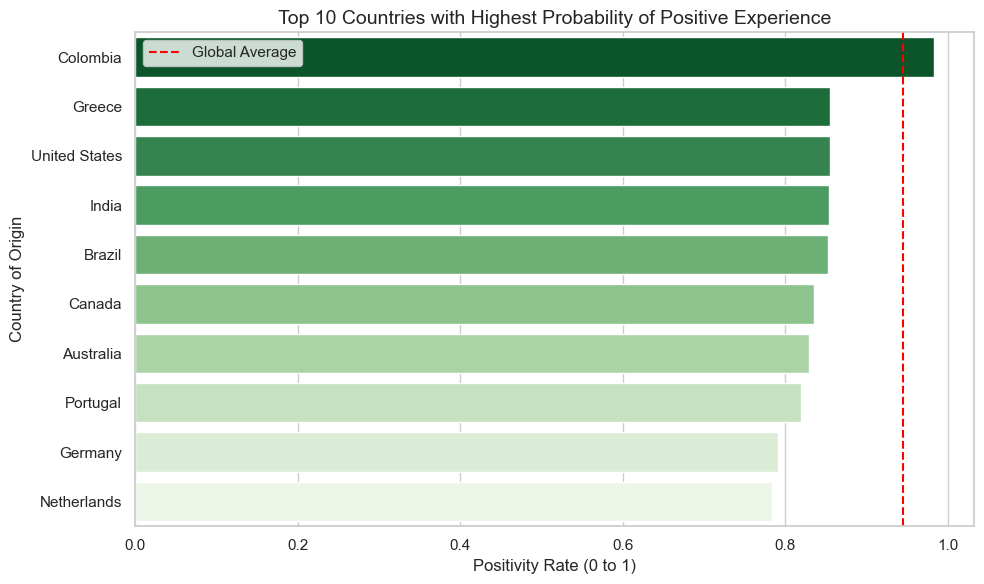

In [102]:
full_data_super_clean = full_data_super_clean[full_data_super_clean['Country_Clean'] != 'Unspecified'].copy()

# Calculate the mean of 'is_positive' (this gives the satisfaction %) and the count of reviews
country_satisfaction = full_data_super_clean.groupby('Country_Clean')['is_positive'].agg(['mean', 'count'])

# Filter out countries with few reviews
robust_countries = country_satisfaction[country_satisfaction['count'] > 50]

# Sort by mean score (descending) and take the Top 10
top_happy_countries = robust_countries.sort_values('mean', ascending=False).head(10)

# Visualization
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_happy_countries['mean'], 
    y=top_happy_countries.index, 
    hue=top_happy_countries.index,  
    palette='Greens_r', 
    legend=False                   
)

plt.title('Top 10 Countries with Highest Probability of Positive Experience', fontsize=14)
plt.xlabel('Positivity Rate (0 to 1)')
plt.ylabel('Country of Origin')

plt.axvline(x=full_data['is_positive'].mean(), color='red', linestyle='--', label='Global Average') 

plt.legend()
plt.tight_layout()
plt.show()